# PaluScope — Phase 0 — 01 Exploration des données (version révisée)

**Blocs A et B** de la feuille de route : compréhension et inspection des données, couleurs et statistiques d'image.
**Version initiale :** Membre 1 (Narcisse ATTIOU) · **Révision :** Membre 2, branche `feature/phase0-quality-analyzer`

**Dataset :** Microscopy Malaria Dataset, split `plasmodium-phonecamera` (Makerere AI Lab, CC0 1.0).
Frottis épais, coloration de Field, ×1000, photos smartphone. Annotations : boîtes englobantes de plasmodiums.

Ce notebook fusionne l'exploration initiale (inventaire, annotations, anomalies) et l'exploration parallèle
(espaces de couleur, statistiques sur toutes les images, cas extrêmes, vues proches, échantillon `data/samples`).
Il s'exécute de haut en bas (**Restart & Run All**), sans dépendre de l'ordre dans lequel les cellules ont été lancées.

## Ce qui a été corrigé par rapport aux deux explorations

| Sujet | Constat | Dans cette version |
|---|---|---|
| Boîtes hors image | 408 boîtes dans un notebook (coordonnées flottantes), 395 dans l'autre | Les coordonnées ne sont jamais arrondies en place. L'arrondi fait « rentrer » les boîtes qui dépassent de moins d'un demi-pixel (cellule de démonstration). Version clippée dans des colonnes séparées `*_c`. |
| « Fichier sans extension » | Signalé comme à identifier | C'est `data/raw/.gitkeep` : `pathlib` donne une extension vide aux fichiers cachés. |
| Écart 7245 / 7628 | Signalé, non exploré | Deux contrôles (boîtes dupliquées, boîtes superposées). Le chiffre 7245 vient de la description publiée du dataset. |
| Statistiques de qualité | 200 images tirées au hasard d'un côté, 1 182 de l'autre | Toutes les images : les extrêmes changent selon l'échantillon. |
| Contraste | Contraste de Michelson (min/max), sensible à un seul pixel | Écart-type et écart p99 − p1. |
| Teinte moyenne | Moyenne arithmétique, puis moyenne circulaire avec un saut entre 0 et 179 | Moyenne circulaire signée (−90 à 90, 0 = rouge) : plus de saut artificiel. |
| Chemins | Chemin relatif et nom du dossier du dataset figés (`plasmodium-phonecamera` ou `plasmodium_phonecamera` selon la machine) | Racine du projet et dossier du dataset détectés automatiquement. |
| Ordre d'exécution | Cellules qui utilisent des variables définies plus bas (`dups`, `show_group`) | Ordre linéaire. |
| Échantillon `data/samples` | Absent d'un côté, règle non documentée de l'autre | 40 images, règle explicite, vérification du dossier et manifeste. |

## 1. Configuration

In [2]:
from collections import Counter
from pathlib import Path
import random
import shutil
import xml.etree.ElementTree as ET

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)

W = H = 750               # dimensions attendues des images (vérifiées en section 3)
N_ANNOUNCED = 7245        # nombre de plasmodiums annoncé par la description publiée du dataset
N_NEG, N_POS = 10, 30     # composition de l'échantillon data/samples (section 11)
DUP_RMS = 2.0             # seuil de différence RMS (miniatures 32×32) pour les vues quasi identiques
CLEAN_SAMPLES = False     # True : supprime de data/samples les images hors sélection (voir section 11)

# Racine du projet : premier dossier parent contenant à la fois data/ et src/
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "data").is_dir() and (p / "src").is_dir())
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
SAMPLES_DIR = ROOT / "data" / "samples"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

# Dossier du dataset : le dossier de data/raw qui contient le plus d'images .jpg
# (son nom varie selon les machines : plasmodium-phonecamera ou plasmodium_phonecamera)
jpg_dirs = Counter(p.parent for p in RAW_DIR.rglob("*") if p.suffix.lower() == ".jpg")
assert jpg_dirs, f"Aucune image .jpg trouvée sous {RAW_DIR}"
DATA_DIR = jpg_dirs.most_common(1)[0][0]

print("Racine du projet   :", ROOT)
print("Dossier du dataset :", DATA_DIR.relative_to(ROOT))

Racine du projet   : /home/juste-agbo/Bureau/PaluScope/PaluScope
Dossier du dataset : data/raw/plasmodium_phonecamera


## 2. Inventaire des fichiers

In [3]:
all_files = [p for p in RAW_DIR.rglob("*") if p.is_file()]
ext_counts = Counter(p.suffix.lower() or f"(sans extension) {p.name}" for p in all_files)
print("Fichiers sous data/raw :", dict(ext_counts))

jpgs = sorted(p for p in DATA_DIR.iterdir() if p.suffix.lower() == ".jpg")
xmls = sorted(p for p in DATA_DIR.iterdir() if p.suffix.lower() == ".xml")
print(f"Images : {len(jpgs)} · Annotations : {len(xmls)}")

jpg_stems = {p.stem for p in jpgs}
xml_stems = {p.stem for p in xmls}
print("Images sans annotation :", len(jpg_stems - xml_stems), sorted(jpg_stems - xml_stems)[:5])
print("Annotations sans image :", len(xml_stems - jpg_stems), sorted(xml_stems - jpg_stems)[:5])

Fichiers sous data/raw : {'(sans extension) .gitkeep': 1, '.jpg': 1182, '.xml': 1182}
Images : 1182 · Annotations : 1182
Images sans annotation : 0 []
Annotations sans image : 0 []


Le « fichier sans extension » repéré dans la première exploration est `data/raw/.gitkeep` : le nom commence par un point,
donc `Path.suffix` renvoie une chaîne vide. Ce n'est pas une donnée du dataset.

## 3. Dimensions, canaux, formats

In [4]:
rows = []
for p in jpgs:
    with Image.open(p) as im:
        rows.append({"stem": p.stem, "width": im.width, "height": im.height,
                     "mode": im.mode, "format": im.format, "size_kb": p.stat().st_size / 1024})
df_img = pd.DataFrame(rows)

print(df_img.groupby(["width", "height", "mode", "format"]).size().to_string())
display(df_img[["size_kb"]].describe().T.round(1))
if not ((df_img.width == W) & (df_img.height == H)).all():
    print("ATTENTION : toutes les images ne font pas", W, "×", H, "- revoir W et H")

width  height  mode  format
750    750     RGB   JPEG      1182


,count,mean,std,min,25%,50%,75%,max
size_kb,1182.0,101.6,7.8,83.8,95.6,102.5,107.6,125.0


## 4. Lecture des annotations

Les `.xml` sont de type Pascal VOC. Aperçu brut d'un fichier avant d'écrire le parseur : les balises sont `<label>` et `<bndbox>`,
et il n'y a pas de balise `<size>`.

In [5]:
print(xmls[0].name)
print(xmls[0].read_text(errors="ignore")[:900])

plasmodium-phone-0001.xml
<annotation>
	<source>
		<database>Makerere Automated Lab Diagnostics Database</database>
		<annotation>Makerere University</annotation>
		<image>Mulago National Referral Hospital</image>
	</source>
	<segmented>0</segmented>
	<object>
		<label>plasmodium</label>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<occluded>0</occluded>
		<bndbox>
			<xmin>290.3885</xmin>
			<ymin>370.8361</ymin>
			<xmax>331.6554</xmax>
			<ymax>410.8361</ymax>
		</bndbox>
	</object>
	<object>
		<label>plasmodium</label>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<occluded>0</occluded>
		<bndbox>
			<xmin>265.0507</xmin>
			<ymin>413.9105</ymin>
			<xmax>305.0507</xmax>
			<ymax>453.9105</ymax>
		</bndbox>
	</object>
	<object>
		<label>plasmodium</label>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<occluded>0</occluded>
		<bndbox>
			<xmin>111.7568</xmin>
			<ymin>264.4172</y


In [6]:
def parse_annotation(path):
    # Lit un fichier d'annotation. Retourne (boîtes en flottants, nombre de boîtes illisibles).
    boxes, bad = [], 0
    for obj in ET.parse(path).getroot().findall("object"):
        bb = obj.find("bndbox")
        try:
            boxes.append({"label": obj.findtext("label"),
                          "xmin": float(bb.findtext("xmin")), "ymin": float(bb.findtext("ymin")),
                          "xmax": float(bb.findtext("xmax")), "ymax": float(bb.findtext("ymax"))})
        except (AttributeError, TypeError, ValueError):
            bad += 1
    return boxes, bad

records, n_bad, n_unreadable = [], 0, 0
for p in xmls:
    try:
        boxes, bad = parse_annotation(p)
    except ET.ParseError:
        n_unreadable += 1
        continue
    n_bad += bad
    records += [{"stem": p.stem, **b} for b in boxes]

df_box = pd.DataFrame(records)
df_box["w"] = df_box.xmax - df_box.xmin
df_box["h"] = df_box.ymax - df_box.ymin
df_box["area"] = df_box.w * df_box.h

print(f"Boîtes lues : {len(df_box)} · boîtes illisibles : {n_bad} · fichiers XML illisibles : {n_unreadable}")
print(df_box.label.value_counts().to_string())
display(df_box[["xmin", "ymin", "xmax", "ymax", "w", "h", "area"]].describe().T.round(1))

Boîtes lues : 7628 · boîtes illisibles : 0 · fichiers XML illisibles : 0
label
plasmodium    7628


,count,mean,std,min,25%,50%,75%,max
xmin,7628.0,350.1,208.4,-19.3,172.6,346.1,526.0,730.0
ymin,7628.0,365.5,207.5,-20.0,192.2,370.8,545.7,730.0
xmax,7628.0,390.0,208.4,21.0,212.6,386.1,565.5,770.0
ymax,7628.0,405.4,207.5,21.0,232.2,410.8,585.7,770.0
w,7628.0,39.9,2.6,1.3,40.0,40.0,40.0,71.4
h,7628.0,39.9,2.4,1.3,40.0,40.0,40.0,62.5
area,7628.0,1598.9,126.9,1.6,1600.0,1600.0,1600.0,3826.5


### 4.1 Boîtes hors de l'image, boîtes très petites

Les coordonnées restent en **flottants** : on ne les arrondit jamais en place, car cela change les comptages aux bords.

In [7]:
out_mask = (df_box.xmin < 0) | (df_box.ymin < 0) | (df_box.xmax > W) | (df_box.ymax > H)
n_out, n_out_img = int(out_mask.sum()), df_box[out_mask].stem.nunique()
print(f"Boîtes dépassant l'image (coordonnées flottantes) : {n_out} sur {n_out_img} images")

# Démonstration : avec des coordonnées arrondies, on retrouve un nombre plus faible.
r = df_box[["xmin", "ymin", "xmax", "ymax"]].round()
n_out_rounded = int(((r.xmin < 0) | (r.ymin < 0) | (r.xmax > W) | (r.ymax > H)).sum())
print(f"Avec coordonnées arrondies : {n_out_rounded} (l'arrondi masque {n_out - n_out_rounded} boîtes ; à ne pas utiliser)")

# Si les boîtes sont des carrés de taille fixe centrés sur un point annoté, les centres restent dans l'image.
cx, cy = (df_box.xmin + df_box.xmax) / 2, (df_box.ymin + df_box.ymax) / 2
print("Centres de boîtes hors de l'image :", int((~(cx.between(0, W) & cy.between(0, H))).sum()))

# Version clippée aux bornes de l'image, dans des colonnes séparées.
for c, lim in (("xmin", W), ("xmax", W), ("ymin", H), ("ymax", H)):
    df_box[c + "_c"] = df_box[c].clip(0, lim)
df_box["w_c"] = df_box.xmax_c - df_box.xmin_c
df_box["h_c"] = df_box.ymax_c - df_box.ymin_c

Boîtes dépassant l'image (coordonnées flottantes) : 408 sur 306 images
Avec coordonnées arrondies : 395 (l'arrondi masque 13 boîtes ; à ne pas utiliser)
Centres de boîtes hors de l'image : 0


In [8]:
for thr in (10, 30):
    m = (df_box.w < thr) | (df_box.h < thr)
    print(f"Boîtes dont un côté est < {thr} px : {int(m.sum())} (dans {df_box[m].stem.nunique()} images)")

tiny = df_box[(df_box.w < 10) | (df_box.h < 10)]
touch = (tiny.xmin <= 0) | (tiny.ymin <= 0) | (tiny.xmax >= W) | (tiny.ymax >= H)
print(f"Parmi les boîtes < 10 px : {int(touch.sum())} touchent un bord de l'image, {int((~touch).sum())} non")
display(tiny[["stem", "xmin", "ymin", "xmax", "ymax", "w", "h"]].head(10).round(1))

share_40 = ((df_box.w.between(38, 42)) & (df_box.h.between(38, 42))).mean()
print(f"Part de boîtes dont les deux côtés sont entre 38 et 42 px : {share_40:.1%}")

Boîtes dont un côté est < 10 px : 25 (dans 23 images)
Boîtes dont un côté est < 30 px : 47 (dans 30 images)
Parmi les boîtes < 10 px : 0 touchent un bord de l'image, 25 non


,stem,xmin,ymin,xmax,ymax,w,h
311,plasmodium-phone-0051,695.7,107.9,697.2,109.4,1.5,1.5
512,plasmodium-phone-0081,369.9,341.4,373.7,342.7,3.8,1.3
559,plasmodium-phone-0089,236.9,304.7,238.2,306.0,1.3,1.3
578,plasmodium-phone-0091,719.5,357.9,721.0,359.4,1.5,1.5
978,plasmodium-phone-0163,490.3,321.2,491.6,322.4,1.3,1.3
1250,plasmodium-phone-0197,443.4,273.0,444.7,274.3,1.3,1.3
2481,plasmodium-phone-0389,295.2,397.2,297.7,398.4,2.5,1.3
2644,plasmodium-phone-0410,50.7,522.6,51.9,523.9,1.3,1.3
2817,plasmodium-phone-0433,551.3,450.1,552.8,451.6,1.5,1.5
3087,plasmodium-phone-0479,533.4,156.5,534.6,157.7,1.3,1.3


Part de boîtes dont les deux côtés sont entre 38 et 42 px : 98.4%


### 4.2 Écart entre 7245 et 7628 boîtes

La description publiée du dataset annonce 7245 plasmodiums dans 1 182 images ; nos fichiers XML en contiennent davantage.
Deux contrôles testent des explications possibles (ils ne prouvent rien s'ils sortent à zéro).

In [9]:
key = ["stem", "xmin", "ymin", "xmax", "ymax"]
n_exact_dup = int(df_box.duplicated(subset=key, keep="first").sum())
print("Boîtes strictement identiques (même image, mêmes coordonnées) :", n_exact_dup)

n_near = 0
for stem, g in df_box.groupby("stem"):
    if len(g) < 2:
        continue
    c = np.c_[(g.xmin + g.xmax) / 2, (g.ymin + g.ymax) / 2]
    d = np.sqrt(((c[:, None, :] - c[None, :, :]) ** 2).sum(-1))
    n_near += int(np.triu(d < 3, k=1).sum())
print("Paires de boîtes aux centres distants de moins de 3 px (même image) :", n_near)
print(f"Écart à expliquer : {len(df_box)} comptées − {N_ANNOUNCED} annoncées = {len(df_box) - N_ANNOUNCED}")

Boîtes strictement identiques (même image, mêmes coordonnées) : 5
Paires de boîtes aux centres distants de moins de 3 px (même image) : 6
Écart à expliquer : 7628 comptées − 7245 annoncées = 383


## 5. Statistiques par image

Images avec au moins un parasite : 948 · sans parasite : 234 (19.8%)


,count,mean,std,min,25%,50%,75%,max
n_objects,1182.0,6.45,5.42,0.0,2.0,6.0,10.0,27.0


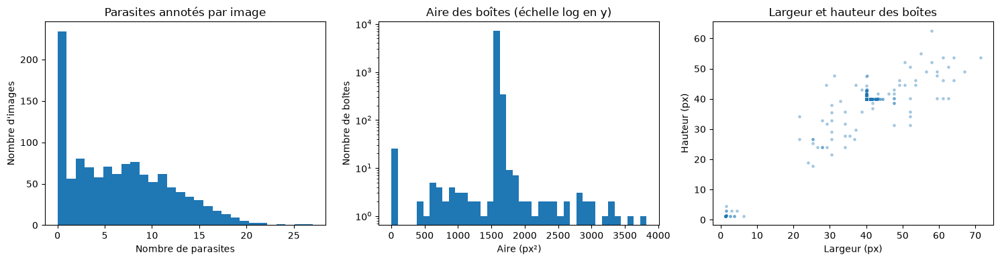

In [10]:
per_img = df_box.groupby("stem").size().rename("n_objects")
df_img = df_img.merge(per_img, on="stem", how="left").fillna({"n_objects": 0})
df_img["n_objects"] = df_img.n_objects.astype(int)

n_neg = int((df_img.n_objects == 0).sum())
print(f"Images avec au moins un parasite : {len(df_img) - n_neg} · sans parasite : {n_neg} ({n_neg / len(df_img):.1%})")
display(df_img.n_objects.describe().round(2).to_frame().T)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(df_img.n_objects, bins=28)
ax[0].set(title="Parasites annotés par image", xlabel="Nombre de parasites", ylabel="Nombre d'images")
ax[1].hist(df_box.area, bins=40)
ax[1].set(title="Aire des boîtes (échelle log en y)", xlabel="Aire (px²)", ylabel="Nombre de boîtes", yscale="log")
ax[2].scatter(df_box.w, df_box.h, s=6, alpha=0.3)
ax[2].set(title="Largeur et hauteur des boîtes", xlabel="Largeur (px)", ylabel="Hauteur (px)")
plt.tight_layout(); plt.show()

## 6. Visualisation d'exemples avec leurs boîtes

Les boîtes tracées sont clippées aux bornes de l'image. Elles font environ 40 px de côté : elles **ne donnent pas la taille réelle
du parasite**, qui apparaît comme une petite tache sombre à l'intérieur.

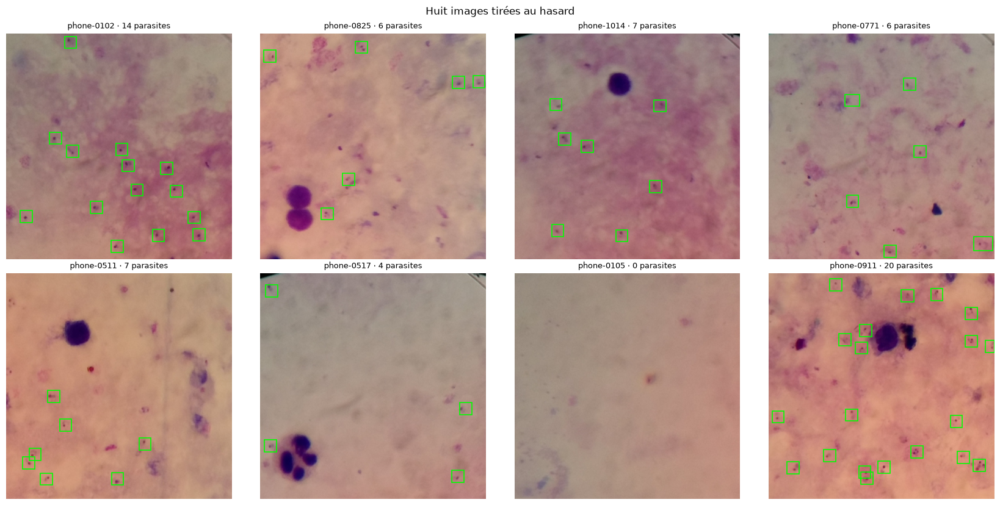

In [11]:
def load_rgb(stem):
    bgr = cv2.imread(str(DATA_DIR / f"{stem}.jpg"))
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def show_with_boxes(stems, ncols=4, title=None):
    nrows = int(np.ceil(len(stems) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.2 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, stem in zip(axes, stems):
        ax.imshow(load_rgb(stem))
        g = df_box[df_box.stem == stem]
        for _, b in g.iterrows():
            ax.add_patch(plt.Rectangle((b.xmin_c, b.ymin_c), b.w_c, b.h_c, fill=False, edgecolor="lime", lw=1.2))
        ax.set_title(f"{stem.replace('plasmodium-', '')} · {len(g)} parasites", fontsize=9)
        ax.axis("off")
    for ax in axes[len(stems):]:
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout(); plt.show()

show_with_boxes(list(rng.choice(df_img.stem, 8, replace=False)), title="Huit images tirées au hasard")

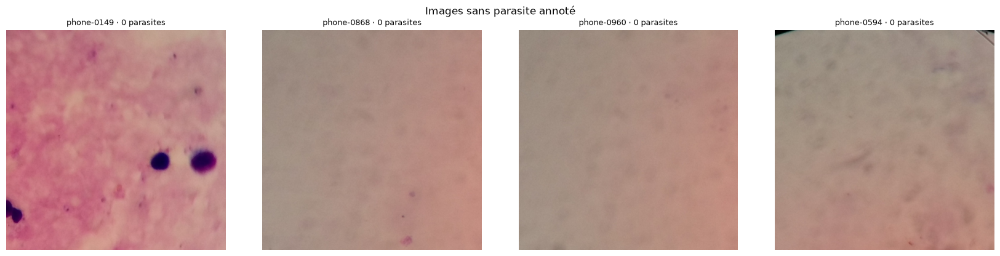

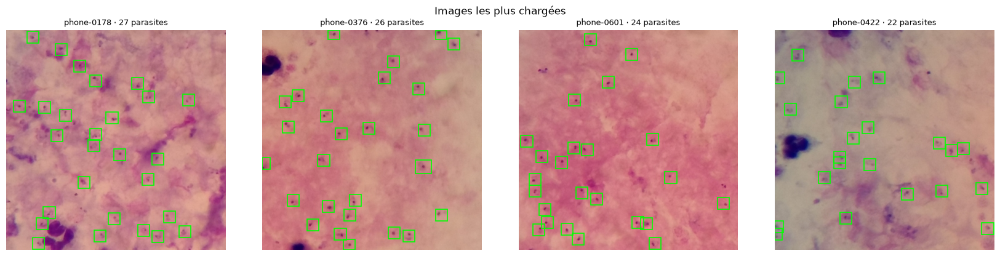

In [12]:
negatives = df_img[df_img.n_objects == 0].stem
dense = df_img.nlargest(4, "n_objects").stem
show_with_boxes(list(rng.choice(negatives, 4, replace=False)), title="Images sans parasite annoté")
show_with_boxes(list(dense), title="Images les plus chargées")

## 7. Espaces de couleur : RGB, niveaux de gris, HSV

Sous OpenCV, la teinte H va de 0 à 179 et S, V de 0 à 255. La teinte est **circulaire** : 0 et 179 sont tous deux du rouge.

plasmodium-phone-0001 · RGB (750, 750, 3) uint8 · gris (750, 750) · HSV (750, 750, 3)


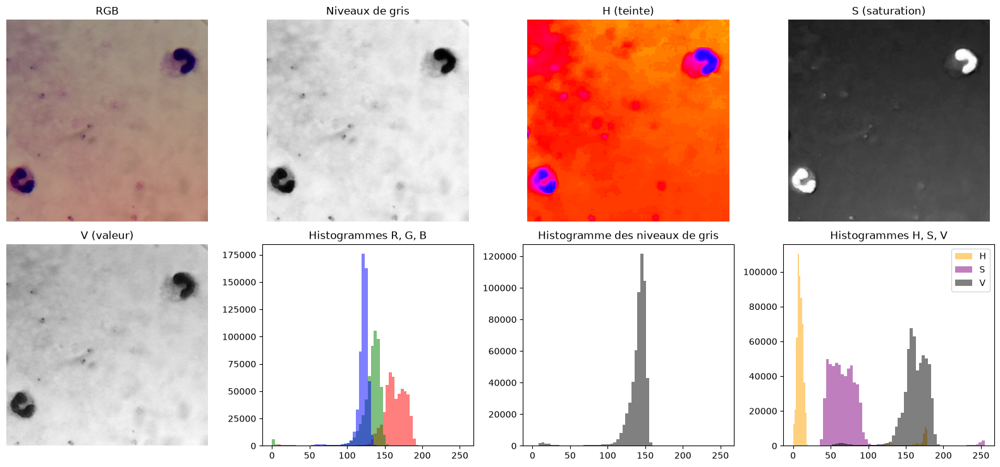

plasmodium-phone-0005 · RGB (750, 750, 3) uint8 · gris (750, 750) · HSV (750, 750, 3)


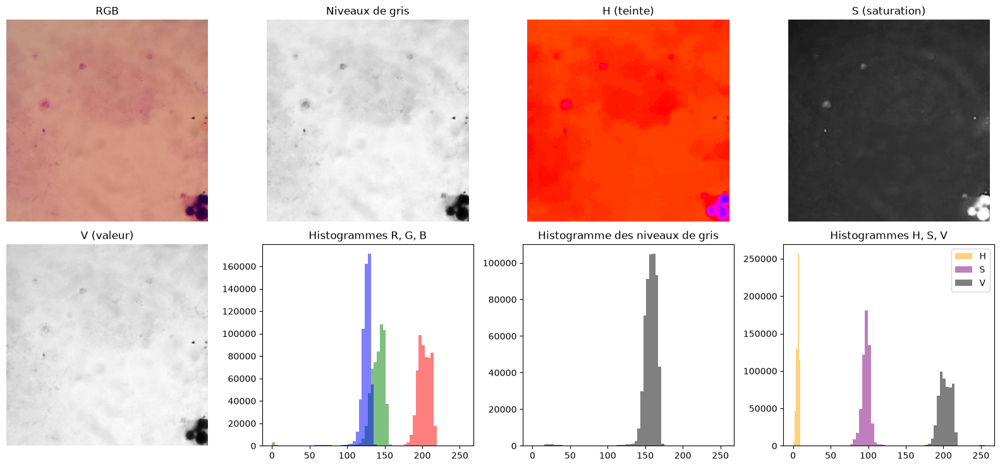

In [13]:
def color_spaces_figure(stem):
    bgr = cv2.imread(str(DATA_DIR / f"{stem}.jpg"))
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    print(f"{stem} · RGB {rgb.shape} {rgb.dtype} · gris {gray.shape} · HSV {hsv.shape}")

    fig, ax = plt.subplots(2, 4, figsize=(16, 7.5))
    ax[0, 0].imshow(rgb);                                   ax[0, 0].set_title("RGB")
    ax[0, 1].imshow(gray, cmap="gray");                     ax[0, 1].set_title("Niveaux de gris")
    ax[0, 2].imshow(hsv[..., 0], cmap="hsv", vmin=0, vmax=179); ax[0, 2].set_title("H (teinte)")
    ax[0, 3].imshow(hsv[..., 1], cmap="gray");              ax[0, 3].set_title("S (saturation)")
    ax[1, 0].imshow(hsv[..., 2], cmap="gray");              ax[1, 0].set_title("V (valeur)")
    for k, col in enumerate("rgb"):
        ax[1, 1].hist(rgb[..., k].ravel(), bins=64, range=(0, 255), color=col, alpha=0.5)
    ax[1, 1].set_title("Histogrammes R, G, B")
    ax[1, 2].hist(gray.ravel(), bins=64, range=(0, 255), color="gray")
    ax[1, 2].set_title("Histogramme des niveaux de gris")
    ax[1, 3].hist(hsv[..., 0].ravel(), bins=90, range=(0, 179), color="orange", alpha=0.5, label="H")
    ax[1, 3].hist(hsv[..., 1].ravel(), bins=64, range=(0, 255), color="purple", alpha=0.5, label="S")
    ax[1, 3].hist(hsv[..., 2].ravel(), bins=64, range=(0, 255), color="black", alpha=0.5, label="V")
    ax[1, 3].legend(); ax[1, 3].set_title("Histogrammes H, S, V")
    for a in ax.ravel()[:5]:
        a.axis("off")
    plt.tight_layout(); plt.show()

color_spaces_figure(df_img.stem.iloc[0])
color_spaces_figure(df_img[df_img.n_objects == 0].stem.iloc[0])

## 8. Statistiques d'image sur les 1 182 images

Indicateurs **exploratoires** : le choix des mesures définitives revient au Quality Analyzer (JusteAgbo05).

In [14]:
def image_stats(stem):
    path = str(DATA_DIR / f"{stem}.jpg")
    bgr = cv2.imread(path)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    b, g, r = bgr.mean(axis=(0, 1))
    p1, p99 = np.percentile(gray, [1, 99])
    # Teinte moyenne circulaire, signée : (−90, 90] en unités OpenCV, 0 = rouge (pas de saut entre 0 et 179)
    h_rad = hsv[..., 0].astype(np.float32) * (2 * np.pi / 180)
    mean_h_circ = np.degrees(np.arctan2(np.sin(h_rad).mean(), np.cos(h_rad).mean())) / 2
    lap_var = cv2.Laplacian(cv2.imread(path, cv2.IMREAD_GRAYSCALE), cv2.CV_64F).var()
    return {
        "stem": stem,
        "mean_gray": gray.mean(), "var_gray": gray.var(), "contrast_std": gray.std(),
        "p1_gray": p1, "p99_gray": p99, "contrast_p99_p1": p99 - p1,
        "mean_R": r, "mean_G": g, "mean_B": b,
        "mean_H_circ": mean_h_circ, "mean_S": hsv[..., 1].mean(), "mean_V": hsv[..., 2].mean(),
        "frac_dark": (gray <= 5).mean(), "frac_sat250": (gray >= 250).mean(),
        "lap_var": lap_var,
    }

df_stats = pd.DataFrame([image_stats(s) for s in df_img.stem])
df_all = df_img.merge(df_stats, on="stem")
df_all.to_csv(PROCESSED_DIR / "phase0_image_stats.csv", index=False)   # data/processed n'est pas versionné
display(df_all.drop(columns=["stem", "format", "mode"]).describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
width,1182.0,750.000,0.000,750.000,750.000,750.000,750.000,750.000
height,1182.0,750.000,0.000,750.000,750.000,750.000,750.000,750.000
size_kb,1182.0,101.609,7.779,83.812,95.636,102.526,107.593,124.970
n_objects,1182.0,6.453,5.418,0.000,2.000,6.000,10.000,27.000
mean_gray,1182.0,146.989,7.560,120.592,141.832,147.638,152.376,169.702
var_gray,1182.0,291.499,228.399,14.769,105.153,243.712,430.151,1502.669
contrast_std,1182.0,15.674,6.771,3.843,10.254,15.611,20.740,38.764
p1_gray,1182.0,78.552,43.114,3.000,35.000,81.000,120.000,151.000
p99_gray,1182.0,165.579,7.078,144.000,161.000,166.000,170.000,189.000
contrast_p99_p1,1182.0,87.026,44.765,16.000,44.250,85.000,132.000,162.000


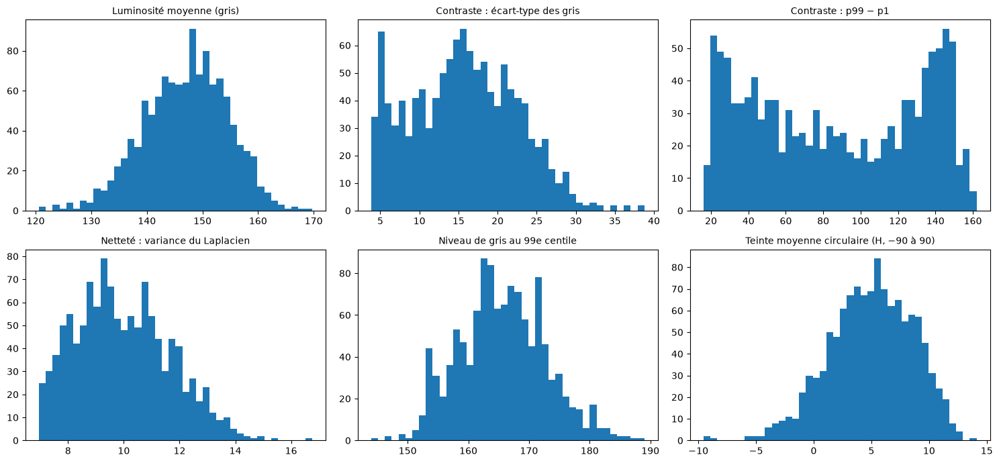

Images avec au moins un pixel de gris ≥ 250 : 0 sur 1182
Niveau de gris au 99e centile : maximum 189.0 · V moyen maximum 209.8
Images avec plus de 0,1 % de pixels quasi noirs (≤ 5), probable vignette : 24


In [15]:
cols = [("mean_gray", "Luminosité moyenne (gris)"), ("contrast_std", "Contraste : écart-type des gris"),
        ("contrast_p99_p1", "Contraste : p99 − p1"), ("lap_var", "Netteté : variance du Laplacien"),
        ("p99_gray", "Niveau de gris au 99e centile"), ("mean_H_circ", "Teinte moyenne circulaire (H, −90 à 90)")]
fig, ax = plt.subplots(2, 3, figsize=(15, 7))
for a, (c, t) in zip(ax.ravel(), cols):
    a.hist(df_all[c], bins=40); a.set_title(t, fontsize=10)
plt.tight_layout(); plt.show()

print("Images avec au moins un pixel de gris ≥ 250 :", int((df_all.frac_sat250 > 0).sum()), "sur", len(df_all))
print("Niveau de gris au 99e centile : maximum", round(df_all.p99_gray.max(), 1), "· V moyen maximum", round(df_all.mean_V.max(), 1))
print("Images avec plus de 0,1 % de pixels quasi noirs (≤ 5), probable vignette :", int((df_all.frac_dark > 0.001).sum()))

La netteté (variance du Laplacien) et le contraste dépendent aussi du **contenu** de l'image : un champ pâle sans cellule a peu de
bords, donc une faible variance du Laplacien, sans être flou. Corrélations de rang sur les 1 182 images :

In [ ]:
display(df_all[["lap_var", "contrast_std", "mean_gray", "n_objects"]].corr(method="spearman").round(2))

## 9. Cas extrêmes

Regarder les images aux extrémités de chaque mesure permet de juger si la mesure capte bien la qualité ou seulement le contenu.

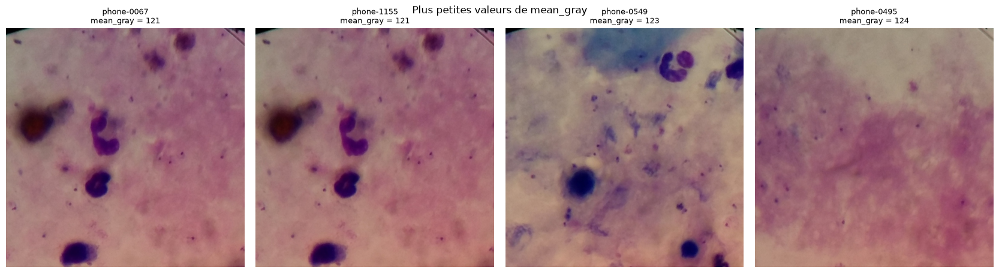

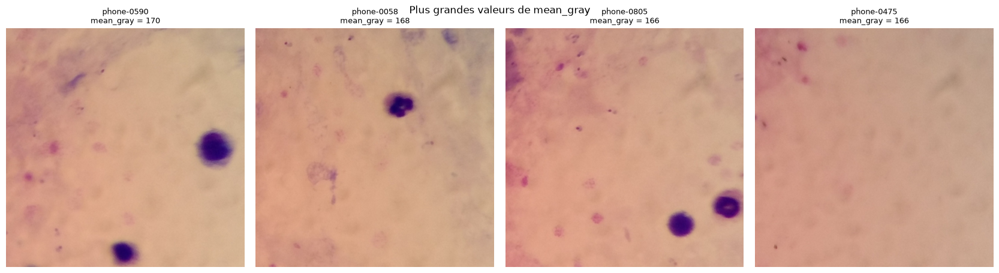

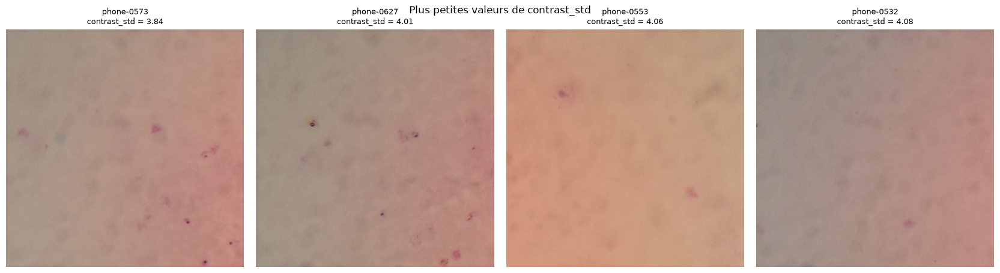

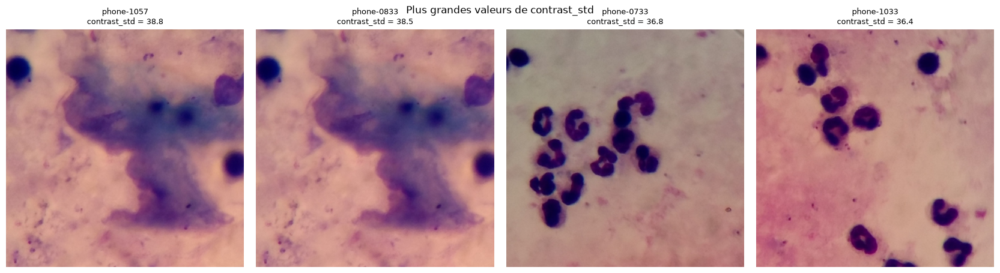

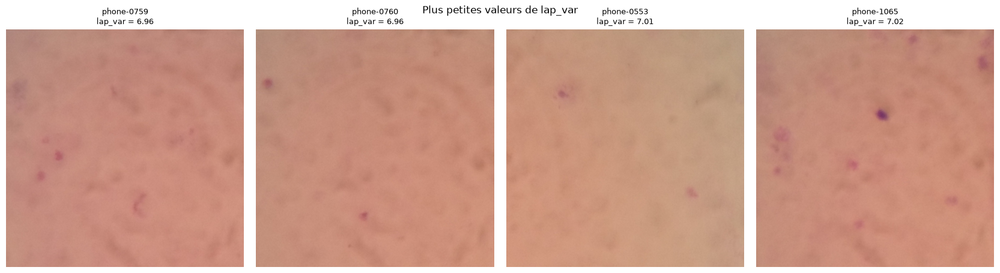

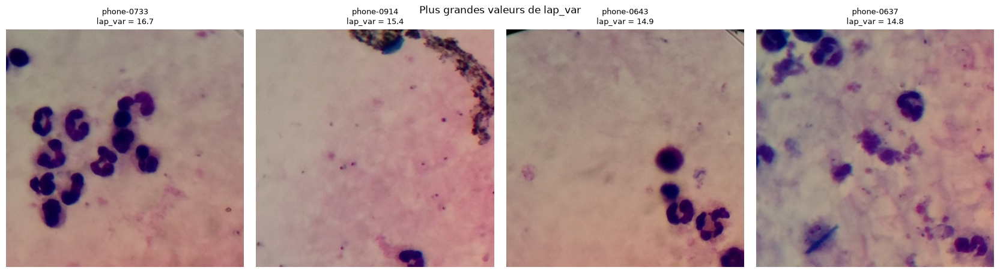

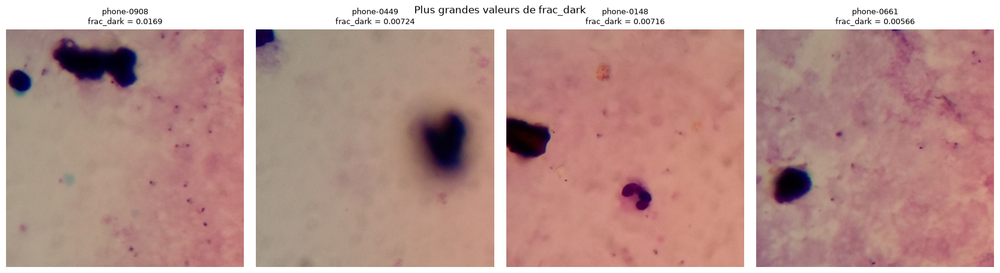

In [16]:
def show_group(col, n=4, largest=False):
    sel = df_all.nlargest(n, col) if largest else df_all.nsmallest(n, col)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4.6))
    for ax, (_, r) in zip(np.atleast_1d(axes), sel.iterrows()):
        ax.imshow(load_rgb(r.stem)); ax.axis("off")
        ax.set_title(f"{r.stem.replace('plasmodium-', '')}\n{col} = {r[col]:.3g}", fontsize=9)
    fig.suptitle(f"{'Plus grandes' if largest else 'Plus petites'} valeurs de {col}")
    plt.tight_layout(); plt.show()

for col in ("mean_gray", "contrast_std", "lap_var"):
    show_group(col, largest=False)
    show_group(col, largest=True)
if df_all.frac_dark.max() > 0:
    show_group("frac_dark", largest=True)

## 10. Images quasi identiques

Plusieurs images peuvent montrer la même lame, voire le même champ. En Phase 1, la règle de séparation train / validation / test
devra éviter de les répartir entre partitions. Le test ci-dessous compare des miniatures 32×32 en niveaux de gris (différence RMS) ;
il détecte les images quasi identiques, mais **pas** les champs simplement décalés ou qui se chevauchent.

In [17]:
def thumb(stem, size=32):
    g = cv2.imread(str(DATA_DIR / f"{stem}.jpg"), cv2.IMREAD_GRAYSCALE)
    return cv2.resize(g, (size, size), interpolation=cv2.INTER_AREA).astype(np.float32).ravel()

T = np.stack([thumb(s) for s in df_img.stem])
sq = (T ** 2).sum(1)
D = np.sqrt(np.maximum(sq[:, None] + sq[None, :] - 2 * T @ T.T, 0)) / np.sqrt(T.shape[1])
np.fill_diagonal(D, np.inf)

i, j = np.where(np.triu(D < DUP_RMS))
dups = (pd.DataFrame({"a": df_img.stem.values[i], "b": df_img.stem.values[j], "rms": D[i, j]})
          .sort_values("rms").reset_index(drop=True))
n_obj = df_img.set_index("stem").n_objects
dups["n_a"], dups["n_b"] = dups.a.map(n_obj).values, dups.b.map(n_obj).values
print(len(dups), f"paires de miniatures quasi identiques (RMS < {DUP_RMS})")
display(dups.head(25).round(2))
dups.to_csv(PROCESSED_DIR / "phase0_near_duplicates.csv", index=False)

multi = pd.concat([dups.a, dups.b]).value_counts()
print("Images présentes dans plusieurs paires :", multi[multi > 1].to_dict())

24 paires de miniatures quasi identiques (RMS < 2.0)


,a,b,rms,n_a,n_b
0,plasmodium-phone-0008,plasmodium-phone-1089,0.47,3,2
1,plasmodium-phone-0802,plasmodium-phone-0916,0.50,0,0
2,plasmodium-phone-0340,plasmodium-phone-0795,0.52,1,1
3,plasmodium-phone-0137,plasmodium-phone-0536,0.61,0,1
4,plasmodium-phone-0367,plasmodium-phone-0603,0.63,6,5
5,plasmodium-phone-0159,plasmodium-phone-0724,0.64,5,4
6,plasmodium-phone-0458,plasmodium-phone-0855,0.68,5,8
7,plasmodium-phone-1030,plasmodium-phone-1046,0.71,2,3
8,plasmodium-phone-0240,plasmodium-phone-0613,0.78,8,7
9,plasmodium-phone-0162,plasmodium-phone-0632,0.81,6,5


Images présentes dans plusieurs paires : {'plasmodium-phone-0420': 2}


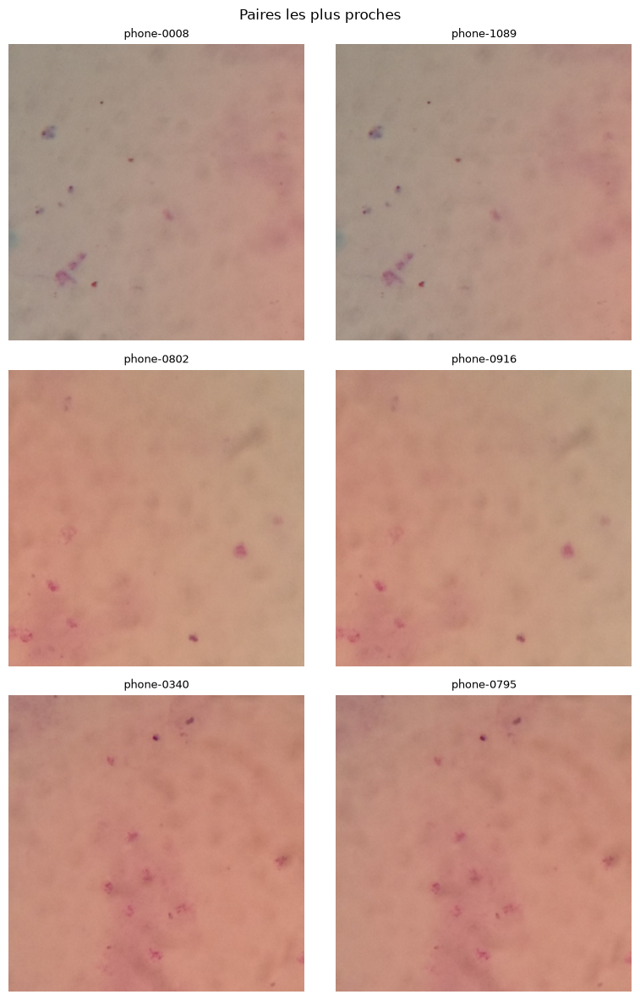

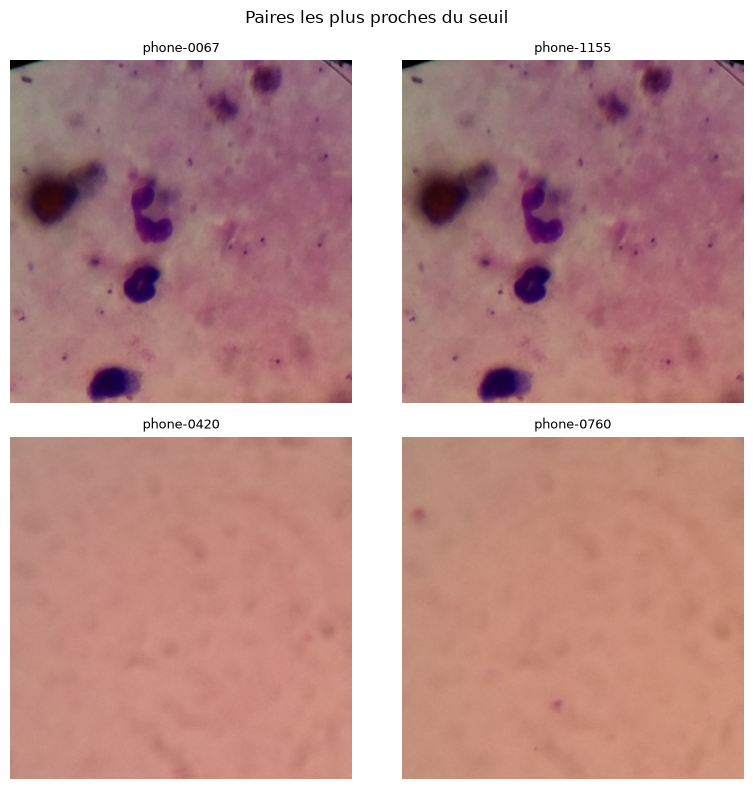

RMS 0067 / 1155 : 1.94 (seuil 2.0)


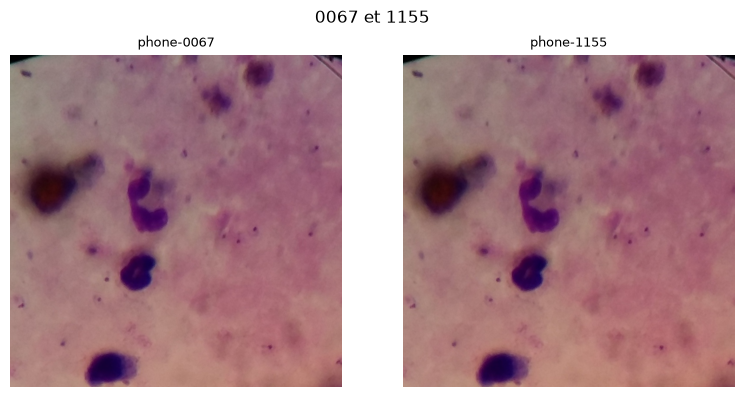

In [18]:
def show_pairs(pairs, title):
    fig, axes = plt.subplots(len(pairs), 2, figsize=(8, 4 * len(pairs)))
    axes = np.atleast_2d(axes)
    for row, (a, b) in zip(axes, pairs):
        for ax, s in zip(row, (a, b)):
            ax.imshow(load_rgb(s)); ax.axis("off")
            ax.set_title(s.replace("plasmodium-", ""), fontsize=9)
    fig.suptitle(title); plt.tight_layout(); plt.show()

if len(dups):
    show_pairs(list(zip(dups.a.head(3), dups.b.head(3))), "Paires les plus proches")
    show_pairs(list(zip(dups.a.tail(2), dups.b.tail(2))), "Paires les plus proches du seuil")

# Cas déjà repéré à l'œil dans les images les plus sombres : sont-elles identiques ou seulement voisines ?
idx = {s: k for k, s in enumerate(df_img.stem)}
pair = ("plasmodium-phone-0067", "plasmodium-phone-1155")
if all(s in idx for s in pair):
    print("RMS 0067 / 1155 :", round(float(D[idx[pair[0]], idx[pair[1]]]), 2), f"(seuil {DUP_RMS})")
    show_pairs([pair], "0067 et 1155")

## 11. Échantillon `data/samples` (40 images)

**Règle de sélection** (déterministe, sans tirage aléatoire) :
1. on écarte la seconde image de chaque paire quasi identique (section 10) ;
2. on prend 10 images **sans** parasite annoté et 30 images **avec** parasites ;
3. dans chaque groupe, les images sont réparties régulièrement sur l'échelle de luminosité moyenne.

L'échantillon couvre ainsi des images pâles, sombres, très colorées, vides ou chargées, ce qui sert de jeu de test local à toute l'équipe.
Le dossier `data/samples` est versionné ; `samples_manifest.csv` indique ce qu'il doit contenir.

In [19]:
keep = df_all[~df_all.stem.isin(set(dups["b"]))]
neg = keep[keep.n_objects == 0]
pos = keep[keep.n_objects > 0]

def spread(df, n, col="mean_gray"):
    o = df.sort_values(col).reset_index(drop=True)
    return o.loc[np.linspace(0, len(o) - 1, n).astype(int), "stem"].tolist()

selection = list(dict.fromkeys(spread(neg, N_NEG) + spread(pos, N_POS)))
n_sel_neg = int((df_all.set_index("stem").loc[selection, "n_objects"] == 0).sum())
print(f"{len(selection)} images sélectionnées ({n_sel_neg} sans parasite, {len(selection) - n_sel_neg} avec)")
if len(selection) != N_NEG + N_POS:
    print(f"ATTENTION : {N_NEG + N_POS} images attendues, {len(selection)} obtenues (un des deux groupes est trop petit).")

present = {p.stem for p in SAMPLES_DIR.glob("*.jpg")}
missing = sorted(set(selection) - present)
extra = sorted(present - set(selection))
print(f"Déjà dans data/samples : {len(present)} · à copier : {len(missing)} · hors sélection : {len(extra)}")
if extra and not CLEAN_SAMPLES:
    print("Hors sélection (conservées ; mettre CLEAN_SAMPLES = True en section 1 pour les supprimer) :", extra[:6], "…")

if CLEAN_SAMPLES:
    for s in extra:
        for ext in (".jpg", ".xml"):
            (SAMPLES_DIR / f"{s}{ext}").unlink(missing_ok=True)
for s in missing:
    for ext in (".jpg", ".xml"):
        shutil.copy(DATA_DIR / f"{s}{ext}", SAMPLES_DIR / f"{s}{ext}")

manifest = (df_all.set_index("stem").loc[selection, ["n_objects", "mean_gray", "contrast_std", "lap_var", "mean_H_circ"]]
            .round(3).reset_index())
manifest.to_csv(SAMPLES_DIR / "samples_manifest.csv", index=False)
print("data/samples contient maintenant", len(list(SAMPLES_DIR.glob("*.jpg"))), "images")

40 images sélectionnées (10 sans parasite, 30 avec)
Déjà dans data/samples : 0 · à copier : 40 · hors sélection : 0
data/samples contient maintenant 40 images


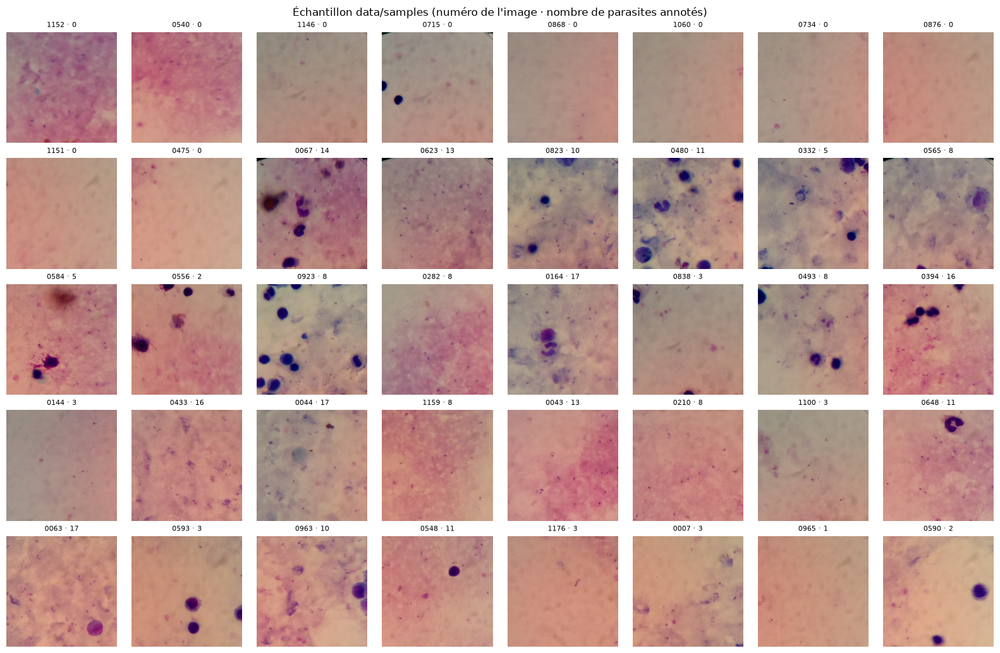

In [20]:
fig, axes = plt.subplots(5, 8, figsize=(16, 10.5))
for ax, s in zip(axes.ravel(), selection):
    ax.imshow(load_rgb(s)); ax.axis("off")
    ax.set_title(f"{s[-4:]} · {int(df_all.set_index('stem').loc[s, 'n_objects'])}", fontsize=8)
for ax in axes.ravel()[len(selection):]:
    ax.axis("off")
fig.suptitle("Échantillon data/samples (numéro de l'image · nombre de parasites annotés)")
plt.tight_layout(); plt.show()

## 12. Résumé chiffré (généré à l'exécution)

In [21]:
print(f"Images / annotations         : {len(jpgs)} / {len(xmls)}")
print(f"Dimensions                   : {sorted(set(zip(df_img.width, df_img.height)))}, modes {sorted(df_img['mode'].unique())}")
print(f"Boîtes lues                  : {len(df_box)} (annoncées : {N_ANNOUNCED}, écart {len(df_box) - N_ANNOUNCED})")
print(f"Images avec / sans parasite  : {len(df_img) - n_neg} / {n_neg}")
print(f"Boîtes hors image            : {n_out} sur {n_out_img} images (à clipper)")
print(f"Boîtes de 38–42 px           : {share_40:.1%}")
print(f"Boîtes strictement dupliquées: {n_exact_dup} · paires de centres < 3 px : {n_near}")
print(f"Paires d'images quasi identiques : {len(dups)}")
print(f"Luminosité moyenne (gris)    : {df_all.mean_gray.min():.0f} – {df_all.mean_gray.max():.0f}")
print(f"Pixels de gris ≥ 250         : {int((df_all.frac_sat250 > 0).sum())} images concernées")
print(f"Images à vignette (> 0,1 % de pixels ≤ 5) : {int((df_all.frac_dark > 0.001).sum())}")
print(f"Échantillon data/samples     : {len(selection)} images sélectionnées")

Images / annotations         : 1182 / 1182
Dimensions                   : [(750, 750)], modes ['RGB']
Boîtes lues                  : 7628 (annoncées : 7245, écart 383)
Images avec / sans parasite  : 948 / 234
Boîtes hors image            : 408 sur 306 images (à clipper)
Boîtes de 38–42 px           : 98.4%
Boîtes strictement dupliquées: 5 · paires de centres < 3 px : 6
Paires d'images quasi identiques : 24
Luminosité moyenne (gris)    : 121 – 170
Pixels de gris ≥ 250         : 0 images concernées
Images à vignette (> 0,1 % de pixels ≤ 5) : 24
Échantillon data/samples     : 40 images sélectionnées


## 13. Observations et anomalies

**Données**
- 1 182 images (`.jpg`) et 1 182 annotations (`.xml`), en correspondance complète. Toutes les images font 750 × 750 px, RGB, JPEG (84 à 125 Ko).
- Annotations de type Pascal VOC : balises `<label>` (une seule classe, `plasmodium`) et `<bndbox>` ; pas de balise `<size>`.
  Provenance indiquée dans les XML : Makerere Automated Lab Diagnostics Database, Mulago National Referral Hospital.
- Aucune métadonnée de lame, de patient ou d'appareil : les images d'une même lame ne sont pas identifiables autrement que par leur ressemblance (section 10).

**Annotations**
- Boîtes de taille quasi fixe (40 × 40 px) : probablement des carrés centrés sur un point annoté. Elles ne donnent pas la taille réelle des parasites.
- Des boîtes dépassent l'image (nombre exact en section 12) : à clipper avant toute comparaison avec des candidats. Les comptages doivent se faire sur les coordonnées non arrondies.
- Quelques boîtes ont un côté de moins de 10 px (section 4.1) : à examiner une par une avant de les écarter.
- L'écart entre 7245 boîtes annoncées et celles lues dans les XML reste à expliquer ; le chiffre 7245 provient de la description publiée du dataset.
- Les grosses cellules violet foncé visibles sur certaines images (probablement des globules blancs) ne sont pas annotées.

**Qualité d'image**
- Luminosité moyenne resserrée ; aucun pixel de gris ≥ 250 : il n'y a pas de saturation dans ce dataset (voir section 12). Le détecteur de surexposition devra être validé sur des images dégradées artificiellement.
- Des pixels quasi noirs en bordure (vignette) existent sur certaines images : à masquer avant seuillage ou calcul de statistiques.
- La variance du Laplacien est faible, resserrée et dépend du contenu ; le contraste global aussi (section 8). Aucune étiquette de qualité n'est fournie : la validation des mesures passera par une comparaison visuelle et des dégradations synthétiques.
- Colorations très variables : tons roses ou beiges, violets ou bleutés.

## 14. À étudier plus tard
- Origine exacte de l'écart 7245 / 7628 boîtes.
- Contraste et netteté mesurés sur le fond ou par zones, pour les séparer du contenu.
- Masque de vignette ; normalisation de la couleur entre images (Phase 1).
- Regroupement des images voisines (même lame ou même champ) avant la séparation train / validation / test.